# Sistema de classificação (Myocardial Infarction Complications)

**Objetivos desta etapa**
- Carregar e explorar o dataset
- Verificar e justificar tratamento de dados faltantes
- Pré-processamento (imputação, scaling)
- Redução de dimensionalidade (PCA)
- Comparar 3 classificadores com validação cruzada e avaliação final

## Instalando o pacote ucimlrepo

In [48]:
pip install ucimlrepo

## Importando o dataset

In [49]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Fetch dataset
myocardial_infarction_complications = fetch_ucirepo(id=579)

# Data (as pandas dataframes)
X = myocardial_infarction_complications.data.features
y = myocardial_infarction_complications.data.targets

# Mostrar estrutura básica
print("Shape de X:", X.shape)
print("Shape de Y:", y.shape)

# Metadados e variáveis
print("\n=== Metadata ===")
print(myocardial_infarction_complications.metadata)

print("\n=== Variáveis ===")
print(myocardial_infarction_complications.variables.head())

Shape de X: (1700, 111)
Shape de Y: (1700, 12)

=== Metadata ===
{'uci_id': 579, 'name': 'Myocardial infarction complications', 'repository_url': 'https://archive.ics.uci.edu/dataset/579/myocardial+infarction+complications', 'data_url': 'https://archive.ics.uci.edu/static/public/579/data.csv', 'abstract': 'Prediction of myocardial infarction complications', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1700, 'num_features': 111, 'feature_types': ['Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC', 'RAZRIV', 'DRESSLER', 'ZSN', 'REC_IM', 'P_IM_STEN', 'LET_IS'], 'index_col': ['ID'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2020, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C53P5M', 'creators': ['S.E. Golovenkin', 'V.A. Shulman', 'D.A. Rossiev', 'P.A. Shesternya', 'S.Yu. Nikulina

## Análise inicial e verificação de dados faltantes

In [50]:
import numpy as np

# Visualização geral
display(X.head())
print("\nInformações do dataframe:")
X.info()

# Verificação de dados faltantes
missing_counts = X.isnull().sum()
missing_perc = (missing_counts / len(X)) * 100
missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_%': missing_perc
}).sort_values(by='missing_%', ascending=False)

print("\nResumo de dados faltantes:")
display(missing_summary.head(15))

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,DLIT_AG,...,NOT_NA_1_n,NOT_NA_2_n,NOT_NA_3_n,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n
0,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,0.0,7.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0
2,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,0.0,2.0,...,3.0,2.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0
3,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
4,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,0.0,7.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0



Informações do dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Columns: 111 entries, AGE to TRENT_S_n
dtypes: float64(110), int64(1)
memory usage: 1.4 MB

Resumo de dados faltantes:


,missing_count,missing_%
KFK_BLOOD,1696,99.764706
IBS_NASL,1628,95.764706
D_AD_KBRIG,1076,63.294118
S_AD_KBRIG,1076,63.294118
NOT_NA_KB,686,40.352941
LID_KB,677,39.823529
NA_KB,657,38.647059
NA_BLOOD,375,22.058824
GIPER_NA,375,22.058824
K_BLOOD,371,21.823529


## Justificativa dos dados faltantes

O dataset **Myocardial Infarction Complications** contém valores faltantes em diversas variáveis,  o que é esperado em registros clínicos reais (por exemplo, exames não realizados ou medições indisponíveis).

Portanto, **não é possível ignorar** essa etapa.
Será aplicada **imputação** utilizando a estratégia de substituição pela **média** (para variáveis numéricas)
ou pelo **valor mais frequente** (para categóricas), mantendo a integridade estatística dos dados.

## Imputação e normalização dos dados

In [51]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Imputação numérica
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Normalização (padronização)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Shape após imputação e normalização:", X_scaled.shape)

Shape após imputação e normalização: (1700, 111)


## Redução de dimensionalidade (PCA - 95% da variância)

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimensão original: {X_scaled.shape[1]} | Dimensão reduzida (95% var): {X_pca.shape[1]}")

Dimensão original: 111 | Dimensão reduzida (95% var): 92


## Divisão treino/teste e configuração da validação cruzada

In [53]:
# Verifique as colunas disponíveis
print("Colunas de target disponíveis:")
print(y.columns.tolist())

# Contar o número de casos positivos (1) em cada coluna
print("\nDistribuição de casos positivos em cada complicação:")
print(y.sum().sort_values(ascending=False))

# Escolha a coluna com número razoável de casos (ex: 'ZSN' = insuficiência cardíaca)
target_col = 'ZSN'  # altere aqui se quiser outra

# Defina o y_target
y_target = y[target_col]

# Verifique a proporção de classes
print("\nDistribuição de classes para o target selecionado:")
print(y_target.value_counts())

# Divisão treino/teste (80/20) com estratificação
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_target, test_size=0.2, random_state=42, stratify=y_target
)

print("\nTrain:", X_train.shape, "| Test:", X_test.shape)

Colunas de target disponíveis:
['FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC', 'RAZRIV', 'DRESSLER', 'ZSN', 'REC_IM', 'P_IM_STEN', 'LET_IS']

Distribuição de casos positivos em cada complicação:
LET_IS        811
ZSN           394
FIBR_PREDS    170
OTEK_LANC     159
REC_IM        159
P_IM_STEN     148
DRESSLER       75
FIBR_JELUD     71
A_V_BLOK       57
RAZRIV         54
JELUD_TAH      42
PREDS_TAH      20
dtype: int64

Distribuição de classes para o target selecionado:
ZSN
0    1306
1     394
Name: count, dtype: int64

Train: (1360, 92) | Test: (340, 92)


## Treinamento e avaliação de três classificadores

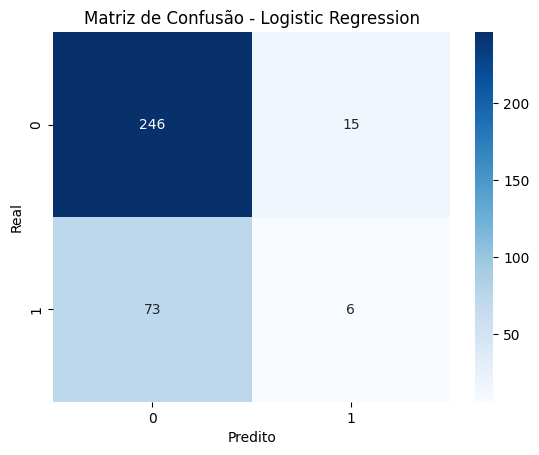

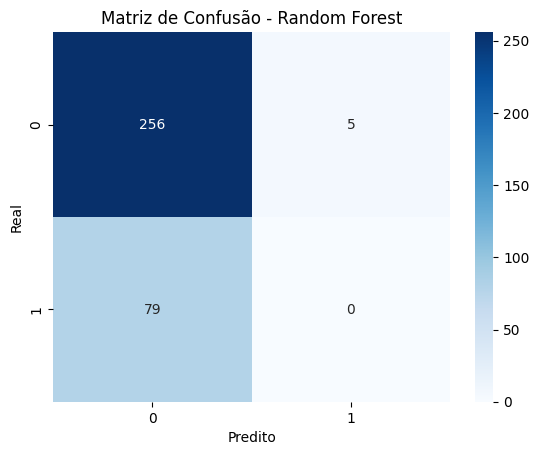

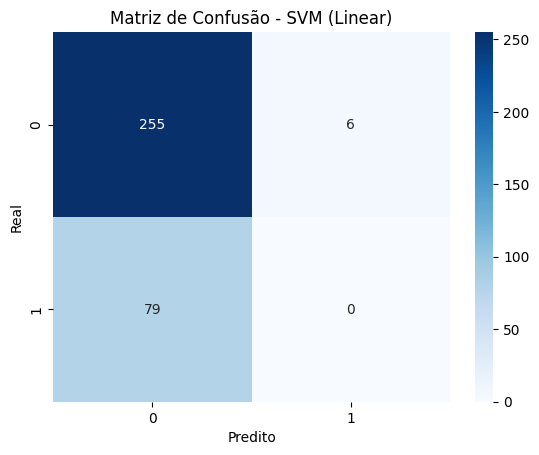

,Modelo,Acurácia,Precisão,Revocação,F1-Score
0,Logistic Regression,0.741176,0.658365,0.741176,0.679059
1,Random Forest,0.752941,0.586620,0.752941,0.659455
2,SVM (Linear),0.750000,0.586078,0.750000,0.657983


In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM (Linear)": SVC(kernel='linear', random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusão - {name}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

results_df = pd.DataFrame(results, columns=["Modelo", "Acurácia", "Precisão", "Revocação", "F1-Score"])
display(results_df)

## Validação cruzada (K-Fold = 5)

In [55]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{name} - Validação Cruzada 5-Fold")
    scores = cross_val_score(model, X_pca, y_target, cv=cv, scoring='accuracy')
    print(f"Acurácia média: {scores.mean():.4f} ± {scores.std():.4f}")


Logistic Regression - Validação Cruzada 5-Fold
Acurácia média: 0.7571 ± 0.0084

Random Forest - Validação Cruzada 5-Fold
Acurácia média: 0.7665 ± 0.0035

SVM (Linear) - Validação Cruzada 5-Fold
Acurácia média: 0.7576 ± 0.0114


/tmp/ipython-input-2239910485.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_target, palette="pastel")


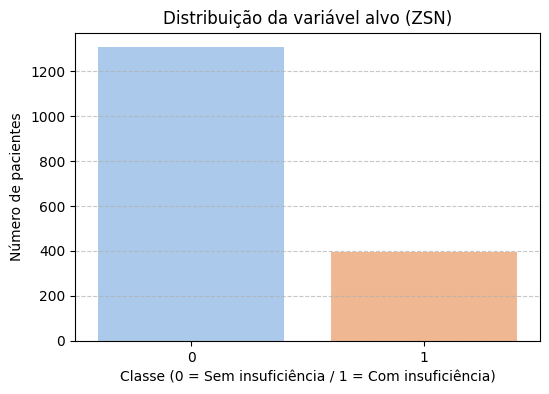

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=y_target, palette="pastel")
plt.title("Distribuição da variável alvo (ZSN)")
plt.xlabel("Classe (0 = Sem insuficiência / 1 = Com insuficiência)")
plt.ylabel("Número de pacientes")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("fig1_distribuicao_zsn.png", dpi=300, bbox_inches="tight")
plt.show()

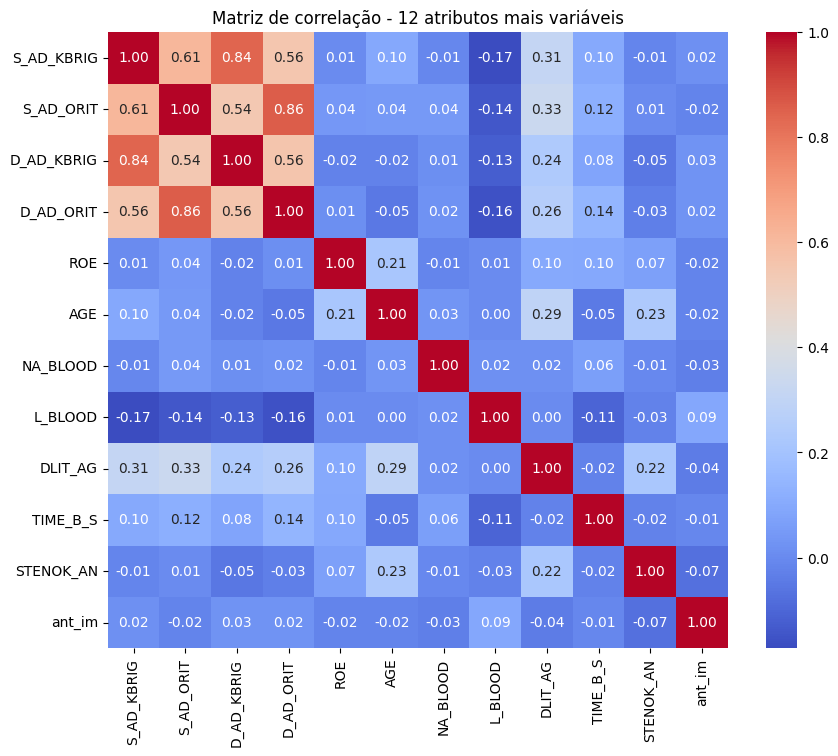

In [57]:
# Selecionar as 12 variáveis com maior variância
variancias = X.var().sort_values(ascending=False)
top_features = variancias.head(12).index
corr = X[top_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlação - 12 atributos mais variáveis")
plt.savefig("fig2_correlacao_top12.png", dpi=300, bbox_inches="tight")
plt.show()

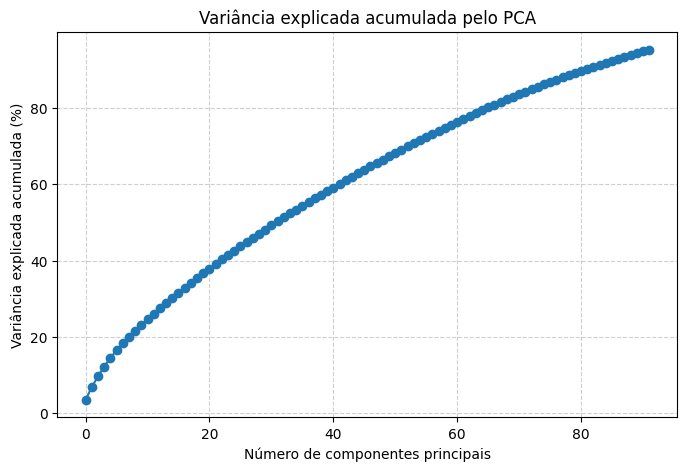

In [58]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100, marker='o')
plt.title("Variância explicada acumulada pelo PCA")
plt.xlabel("Número de componentes principais")
plt.ylabel("Variância explicada acumulada (%)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("fig3_pca_variancia.png", dpi=300, bbox_inches="tight")
plt.show()